In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

In [2]:
# Загрузка датасета
music = pd.read_csv('low_popularity_spotify_data.csv')

# Проверка размерности
print(f'Размерность датасета: {music.shape[0]} строк и {music.shape[1]} столбцов')

# Визуальный контроль данных
display(music.head())  # Первые 5 строк
display(music.tail())  # Последние 5 строк

# Технический аудит признаков:
# Выявляем типы и наличие явных пропусков
print("\n---Техническая информация о столбцах---")
music.info()

# Анализируем средние значения, стандартное отклонение и квартили для аудио-фич
print("\n---Описательная статистика численных признаков---")
music.describe()

Размерность датасета: 3145 строк и 29 столбцов


,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,4A8gFwqd9jTtnsNwUu3OQx,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,2c965LEDRNrXXCeBOAAwns,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,3S404OgKoVQSJ3xXrDVlp8,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition)
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,1y5KGkUKO0NG32MhIIagCA,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella"
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,6f4b9wVTkKAf096k4XG6x5,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter


,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
3140,1.0,33,0.0634,0.352,Carnatic Classics,M. S. Subbulakshmi,661293.0,0.424,indian,classical,...,5utDQUWCZCEXWHMmna8C63,3sIB6VOssssCO17VUPu80m,1IkR0OgVI1gydC4S6jnG2B,0.605,10.0,75.466,-8.009,0.965,0.2420,Bhaja Govindam - Vishnu Sahasranamam
3141,4.0,22,0.0656,0.471,Carnatic Classics,Jayanthi Kumaresh,394400.0,0.349,indian,classical,...,4kUGwkHXKBbaLwnqTIrg0J,3sIB6VOssssCO17VUPu80m,4ZFM5yFsjEzvZ1XmP27L5r,0.358,8.0,147.193,-16.633,0.975,0.2860,Veenai Jayanthi Kumaresh
3142,4.0,18,0.0671,0.436,Carnatic Classics,"Nirmala Rajasekar, Raghavendra Rao, Tanjore K....",473440.0,0.595,indian,classical,...,6FMROVG9PB4nJYmvNLTdge,3sIB6VOssssCO17VUPu80m,5wZQXUcphAyBZfVdWmAiYX,0.870,3.0,174.308,-11.494,0.816,0.0939,Into the Raga
3143,1.0,23,0.0813,0.489,Carnatic Classics,Ganesh & Kumaresh,298987.0,0.591,indian,classical,...,3si4Lr5oBcahJ3D7IPbO4N,3sIB6VOssssCO17VUPu80m,5Ca5l5vDzIOZdVwwWCxAds,0.689,8.0,174.760,-10.843,0.948,0.0770,Thillanas: A Confluence Of Rhythm & Melody
3144,4.0,14,0.0598,0.270,Carnatic Classics,Sudha Ragunathan,645701.0,0.816,indian,classical,...,2tezom8oCCpSeiriOFeZNi,3sIB6VOssssCO17VUPu80m,0HmenrANrrNVi8244GsYB5,0.591,8.0,170.938,-3.815,0.853,0.3170,Gems of Carnatic Music: Sudha Raghunathan (Liv...



---Техническая информация о столбцах---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3145 entries, 0 to 3144
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time_signature            3144 non-null   float64
 1   track_popularity          3145 non-null   int64  
 2   speechiness               3144 non-null   float64
 3   danceability              3144 non-null   float64
 4   playlist_name             3145 non-null   object 
 5   track_artist              3145 non-null   object 
 6   duration_ms               3144 non-null   float64
 7   energy                    3144 non-null   float64
 8   playlist_genre            3145 non-null   object 
 9   playlist_subgenre         3145 non-null   object 
 10  track_href                3144 non-null   object 
 11  track_name                3145 non-null   object 
 12  mode                      3144 non-null   float64
 13  uri                   

,time_signature,track_popularity,speechiness,danceability,duration_ms,energy,mode,instrumentalness,valence,key,tempo,loudness,acousticness,liveness
count,3144.000000,3145.000000,3144.000000,3144.000000,3.144000e+03,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000
mean,3.929389,43.479173,0.102174,0.607268,2.016402e+05,0.543509,0.553435,0.286603,0.458438,5.177163,116.766884,-10.663833,0.405567,0.165487
std,0.447827,14.821766,0.101726,0.200372,9.157390e+04,0.263635,0.497216,0.395181,0.266140,3.565412,29.152400,8.155066,0.342249,0.124652
min,1.000000,11.000000,0.021900,0.058900,3.537500e+04,0.000202,0.000000,0.000000,0.029600,0.000000,48.232000,-48.069000,0.000004,0.022000
25%,4.000000,32.000000,0.038800,0.509000,1.518962e+05,0.357750,0.000000,0.000000,0.232000,2.000000,94.889250,-11.999750,0.084100,0.096400
50%,4.000000,46.000000,0.055000,0.649500,1.846410e+05,0.592000,1.000000,0.001060,0.462000,5.000000,116.052000,-8.026000,0.316000,0.116000
75%,4.000000,55.000000,0.118000,0.753000,2.264302e+05,0.747000,1.000000,0.788000,0.673000,8.000000,136.706500,-5.831000,0.725250,0.189000
max,5.000000,68.000000,0.927000,0.977000,1.355260e+06,0.998000,1.000000,0.991000,0.987000,11.000000,241.426000,1.318000,0.996000,0.979000


In [3]:
# Диагностика пропущенных значений (NaN)
# Считаем количество пропусков по каждому признаку
print("--- Пропущенные значения до обработки ---")
print(music.isnull().sum())

# Удаляем строки с пропусками
music.dropna(inplace=True)

# Диагностика дубликатов
print(f"\nОбнаружено полных дубликатов: {music.duplicated().sum()}")

# Удаление повторов, оставляем только уникальные записи
music.drop_duplicates(inplace=True)

# 5. Итоговая проверка после фильтрации
print("\n--- Проверка после очистки ---")
print(f"Осталось строк после удаления NaN и дубликатов: {len(music)}")
print(f"Осталось дубликатов: {music.duplicated().sum()}")

--- Пропущенные значения до обработки ---
time_signature              1
track_popularity            0
speechiness                 1
danceability                1
playlist_name               0
track_artist                0
duration_ms                 1
energy                      1
playlist_genre              0
playlist_subgenre           0
track_href                  1
track_name                  0
mode                        1
uri                         1
type                        1
track_album_release_date    0
analysis_url                1
id                          1
instrumentalness            1
track_album_id              0
playlist_id                 0
track_id                    0
valence                     1
key                         1
tempo                       1
loudness                    1
acousticness                1
liveness                    1
track_album_name            0
dtype: int64

Обнаружено полных дубликатов: 0

--- Проверка после очистки ---
Осталось с

In [4]:
# Использование коэффициента 1.5 для более строгой фильтрации "речевого" контента
mean_s = music['speechiness'].mean()
std_s = music['speechiness'].std()

# Верхняя граница
upper_limit = mean_s + 1.5 * std_s 
# Нижняя граница
lower_limit = mean_s - 1.5 * std_s

# Выделяем строки, которые признаны выбросами
outliers_detected = music.loc[(music['speechiness'] > upper_limit) | (music['speechiness'] < lower_limit)]

# Создаем очищенный датасет, исключая выбросы
music_cleaned = music.loc[(music['speechiness'] <= upper_limit) & (music['speechiness'] >= lower_limit)].copy()

# Отчет по результатам очистки
print("--- Отчет по обработке выбросов ---")
print(f'Записей в исходном наборе:  {len(music)}')
print(f'Удалено аномальных треков:  {len(outliers_detected)}')
print(f'Записей в очищенном наборе: {len(music_cleaned)}')

--- Отчет по обработке выбросов ---
Записей в исходном наборе:  3144
Удалено аномальных треков:  355
Записей в очищенном наборе: 2789


In [5]:
# Инициализируем инструмент для преобразования текста в числа
le = LabelEncoder()

# Создаем новый столбец 'genre_id'
music_cleaned['genre_id'] = le.fit_transform(music_cleaned['playlist_genre'])

# Выведем "словарь" соответствия
genre_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("--- Карта соответствия жанров ---")
print(genre_mapping)

# Контрольная проверка последних 15 строк (выводим оба столбца для сравнения)
music_cleaned[['playlist_genre', 'genre_id']].tail(15)

--- Карта соответствия жанров ---
{'afrobeats': 0, 'ambient': 1, 'arabic': 2, 'blues': 3, 'brazilian': 4, 'cantopop': 5, 'classical': 6, 'country': 7, 'disco': 8, 'electronic': 9, 'folk': 10, 'funk': 11, 'gaming': 12, 'gospel': 13, 'hip-hop': 14, 'indian': 15, 'indie': 16, 'j-pop': 17, 'jazz': 18, 'k-pop': 19, 'korean': 20, 'latin': 21, 'lofi': 22, 'mandopop': 23, 'metal': 24, 'pop': 25, 'punk': 26, 'reggae': 27, 'rock': 28, 'soca': 29, 'soul': 30, 'turkish': 31, 'wellness': 32, 'world': 33}


,playlist_genre,genre_id
3129,pop,25
3130,pop,25
3131,pop,25
3133,pop,25
3134,pop,25
3135,pop,25
3136,indian,15
3137,indian,15
3138,indian,15
3139,indian,15


In [6]:
# Выбор ключевых аудио-признаков для кластеризации
features_to_scale = ['tempo', 'loudness', 'acousticness', 'liveness']
X_raw = music_cleaned[features_to_scale]

# Стандартизация (StandardScaler)
# Приводит данные к среднему = 0 и стандартному отклонению = 1.
scaler_std = StandardScaler()
X_std_array = scaler_std.fit_transform(X_raw)

# Превращаем обратно в DataFrame для удобства анализа
X_std = pd.DataFrame(X_std_array, columns=features_to_scale)

print("--- Результаты Стандартизации ---")
print(X_std.describe().loc[['mean', 'std', 'min', 'max']])


# Нормализация (MinMaxScaler)
# Сжимает данные в диапазон от 0 до 1. 
scaler_mm = MinMaxScaler(feature_range=(0, 1))
X_norm_array = scaler_mm.fit_transform(X_raw)

X_norm = pd.DataFrame(X_norm_array, columns=features_to_scale)

print("\n--- Результаты Нормализации ---")
X_norm.head()

--- Результаты Стандартизации ---
             tempo      loudness  acousticness      liveness
mean  5.681285e-16 -3.057194e-17 -1.783363e-16 -1.299307e-16
std   1.000179e+00  1.000179e+00  1.000179e+00  1.000179e+00
min  -2.388265e+00 -4.357412e+00 -1.194218e+00 -1.166536e+00
max   4.404910e+00  1.462872e+00  1.651349e+00  6.879501e+00

--- Результаты Нормализации ---


,tempo,loudness,acousticness,liveness
0,0.435200,0.896673,0.065057,0.157785
1,0.423145,0.847389,0.171684,0.050366
2,0.327262,0.825521,0.328311,0.062487
3,0.146185,0.628242,0.916666,0.176594
4,0.166957,0.777087,0.788152,0.211076


In [7]:
pop_data = music_cleaned['track_popularity']

# Расчет центральных тенденций и мер разброса
m_std = pop_data.std()    # Стандартное отклонение
m_mean = pop_data.mean()   # Среднее арифметическое значение популярности
m_median = pop_data.median() # Медиана

# Квартильный анализ (разбиение данных на 4 равные части)
q0 = np.quantile(pop_data, 0)    # Минимум
q1 = np.quantile(pop_data, 0.25) # 1-й квартиль
q2 = np.quantile(pop_data, 0.5)  # 2-й квартиль (Медиана)
q3 = np.quantile(pop_data, 0.75) # 3-й квартиль
q4 = np.quantile(pop_data, 1.0)  # Максимум

print(f"--- Сводная статистика популярности ---")
print(f"Среднее значение: {m_mean:.2f}")
print(f"Медиана: {m_median}")
print(f"Станд. отклонение: {m_std:.2f}")
print(f"\n--- Квартили ---")
print(f"Мин: {q0} \nQ1 (1-й квартиль): {q1} \nQ2 (2-й квартиль): {q2} \nQ3 (1-й квартиль): {q3} \nМакс: {q4}")

--- Сводная статистика популярности ---
Среднее значение: 43.23
Медиана: 46.0
Станд. отклонение: 14.85

--- Квартили ---
Мин: 11 
Q1 (1-й квартиль): 32.0 
Q2 (2-й квартиль): 46.0 
Q3 (1-й квартиль): 55.0 
Макс: 68.0


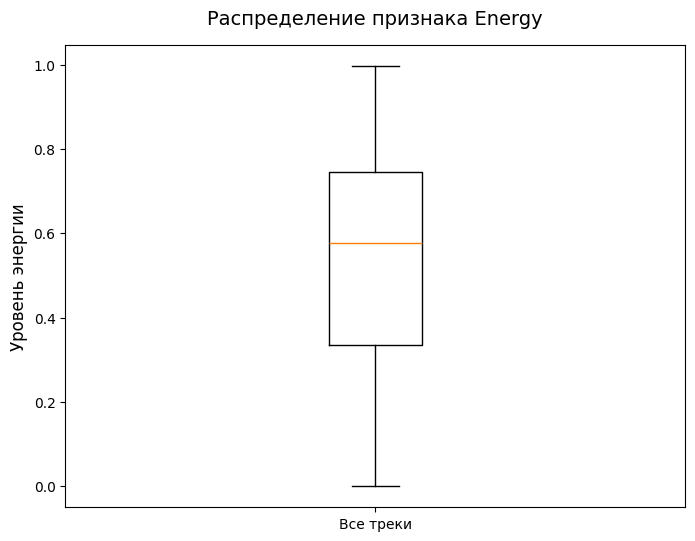

In [8]:
# Настраиваем размер графика
plt.figure(figsize=(8, 6))

plt.boxplot(music_cleaned['energy'])

plt.title('Распределение признака Energy', fontsize=14, pad=15)
plt.ylabel('Уровень энергии', fontsize=12)
plt.xticks([1], ['Все треки'])

plt.show()

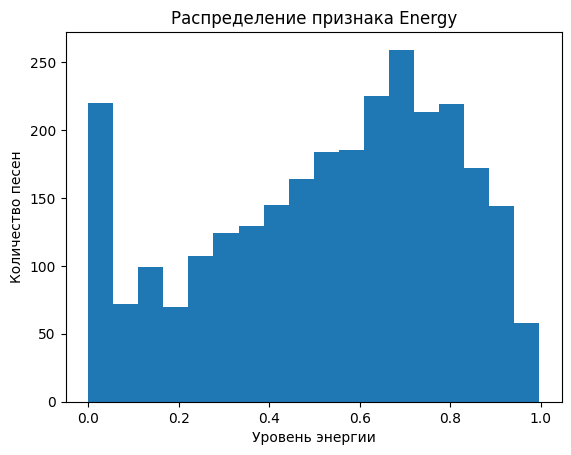

In [9]:
# Строим гистограмму распределения энергии
plt.hist(music_cleaned['energy'], bins='auto')

# Добавляем подписи
plt.title('Распределение признака Energy')
plt.xlabel('Уровень энергии')
plt.ylabel('Количество песен')

plt.show()

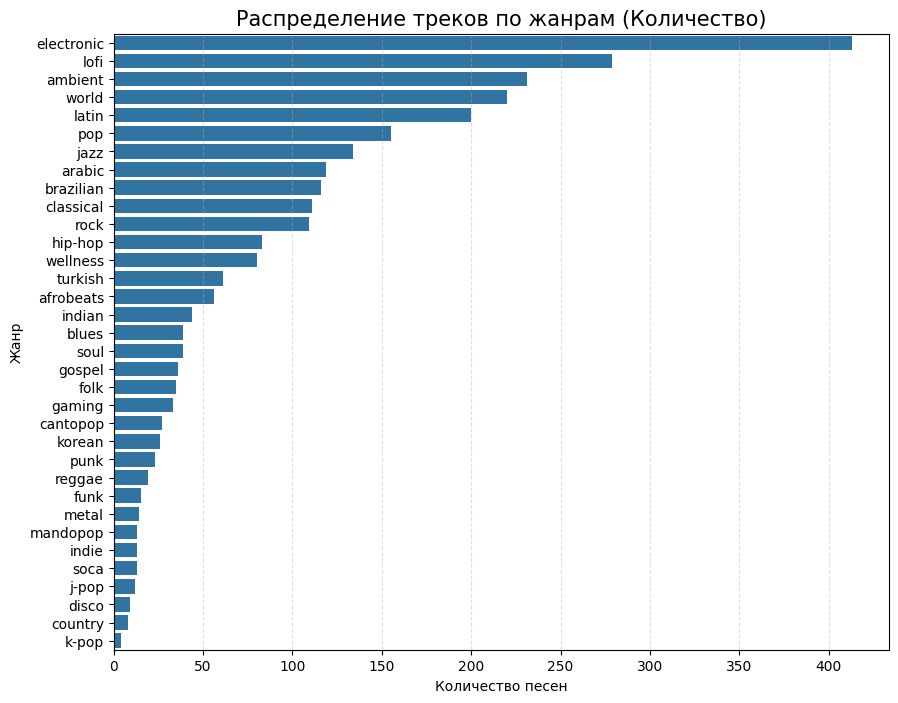

In [10]:
plt.figure(figsize=(10, 8))

sns.countplot(y='playlist_genre', 
              data=music_cleaned,  
              order=music_cleaned['playlist_genre'].value_counts().index)

plt.title('Распределение треков по жанрам (Количество)', fontsize=15)
plt.xlabel('Количество песен')
plt.ylabel('Жанр')

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

,time_signature,track_popularity,speechiness,danceability,duration_ms,energy,mode,instrumentalness,valence,key,tempo,loudness,acousticness,liveness,genre_id
time_signature,1.000000,-0.006732,0.098249,0.228870,-0.009952,0.214871,-0.015854,-0.152199,0.152751,0.002376,-0.011132,0.241755,-0.208166,0.023178,0.020742
track_popularity,-0.006732,1.000000,0.099000,0.074182,-0.061262,0.012353,-0.032563,0.005439,-0.010109,0.025059,0.000918,-0.000934,-0.040836,-0.000506,-0.078995
speechiness,0.098249,0.099000,1.000000,0.289790,-0.061729,0.223991,-0.057694,-0.239820,0.241850,0.022139,0.042658,0.226935,-0.177720,0.080992,-0.094451
danceability,0.228870,0.074182,0.289790,1.000000,-0.116468,0.504307,-0.144832,-0.380211,0.584117,0.032603,0.057550,0.643432,-0.455661,0.035287,0.014554
duration_ms,-0.009952,-0.061262,-0.061729,-0.116468,1.000000,0.132792,0.028884,-0.146031,-0.026879,0.005231,0.052513,0.075339,-0.120187,0.013704,-0.109558
energy,0.214871,0.012353,0.223991,0.504307,0.132792,1.000000,-0.092074,-0.603243,0.546367,0.040665,0.214111,0.817128,-0.785806,0.204424,-0.026734
mode,-0.015854,-0.032563,-0.057694,-0.144832,0.028884,-0.092074,1.000000,0.046764,-0.085218,-0.145931,-0.006844,-0.132241,0.071438,-0.019165,0.001958
instrumentalness,-0.152199,0.005439,-0.239820,-0.380211,-0.146031,-0.603243,0.046764,1.000000,-0.485377,-0.023463,-0.132815,-0.626910,0.529375,-0.136719,0.026701
valence,0.152751,-0.010109,0.241850,0.584117,-0.026879,0.546367,-0.085218,-0.485377,1.000000,0.047912,0.122352,0.532540,-0.407070,0.064527,0.012810
key,0.002376,0.025059,0.022139,0.032603,0.005231,0.040665,-0.145931,-0.023463,0.047912,1.000000,0.002899,0.051668,-0.027835,0.038073,0.007614


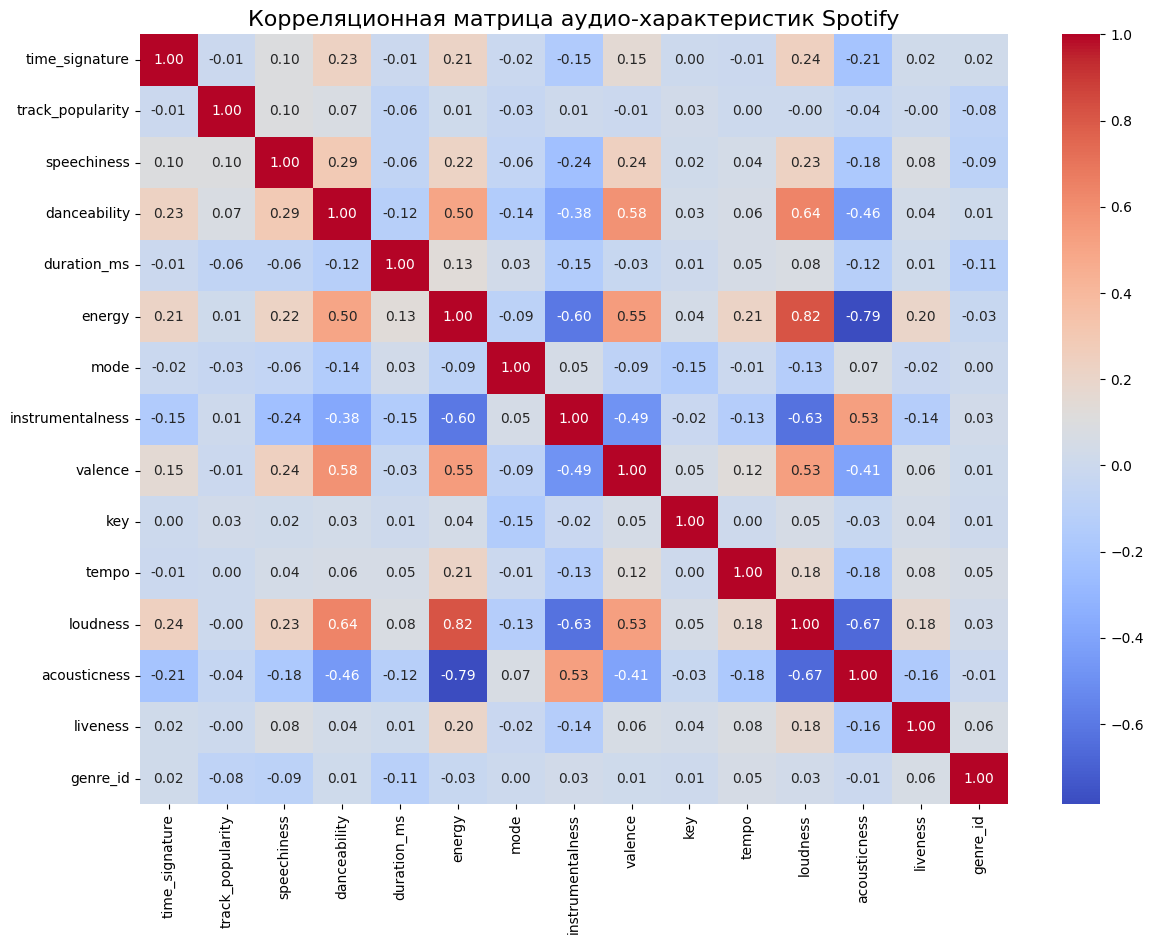

In [11]:
# Рассчитываем матрицу корреляции Пирсона
corr_matrix = music_cleaned.corr(numeric_only=True)

display(corr_matrix)
# Настраиваем размер графика
plt.figure(figsize=(14, 10))

# Строим Heatmap с профессиональными настройками
sns.heatmap(corr_matrix, 
            annot=True,         # Выводим числовые значения коэффициентов в ячейках
            cmap='coolwarm',    # Цветовая схема: Красный (положительная), Синий (отрицательная)
            fmt='.2f')        # Оставляем 2 знака после запятой

plt.title('Корреляционная матрица аудио-характеристик Spotify', fontsize=16)

plt.show()

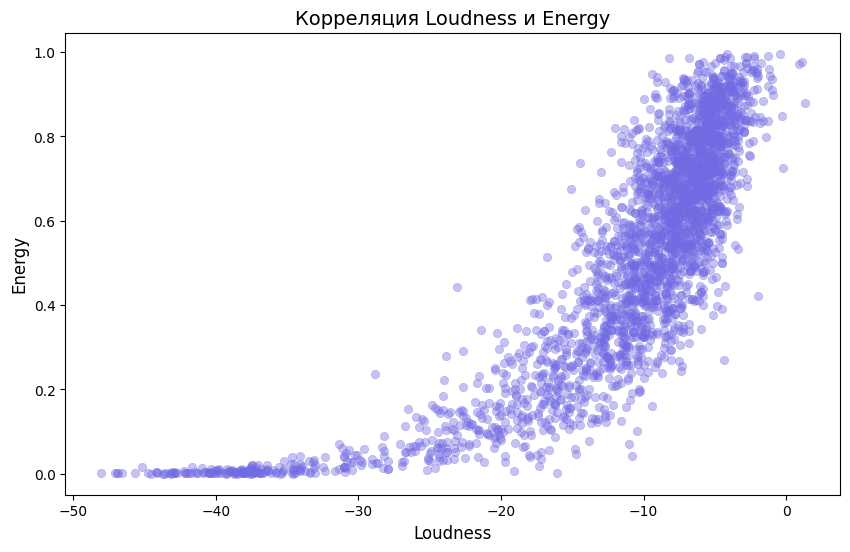

In [12]:
plt.figure(figsize=(10, 6))

# Добавляем параметр alpha (прозрачность), чтобы видеть плотность данных
plt.scatter(music_cleaned['loudness'], 
            music_cleaned['energy'], 
            color='#716be3', 
            alpha=0.4,  
            linewidth=0.5)

plt.title('Корреляция Loudness и Energy', fontsize=14)
plt.xlabel('Loudness', fontsize=12)
plt.ylabel('Energy', fontsize=12)

plt.show()

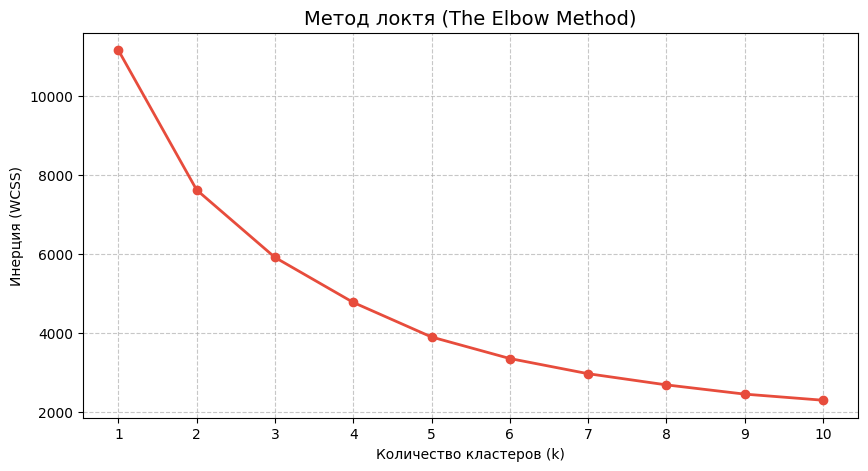

In [13]:
def num_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.plot(means, inertias, 'o-', color='#e74c3c', linewidth=2)
    plt.title('Метод локтя (The Elbow Method)', fontsize=14)
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Инерция (WCSS)')
    plt.xticks(means)
    plt.grid(True, linestyle='--', alpha=0.7)

    
    plt.show()

# Запускаем на стандартизированных данных
num_k_means(X_std_array, 10)

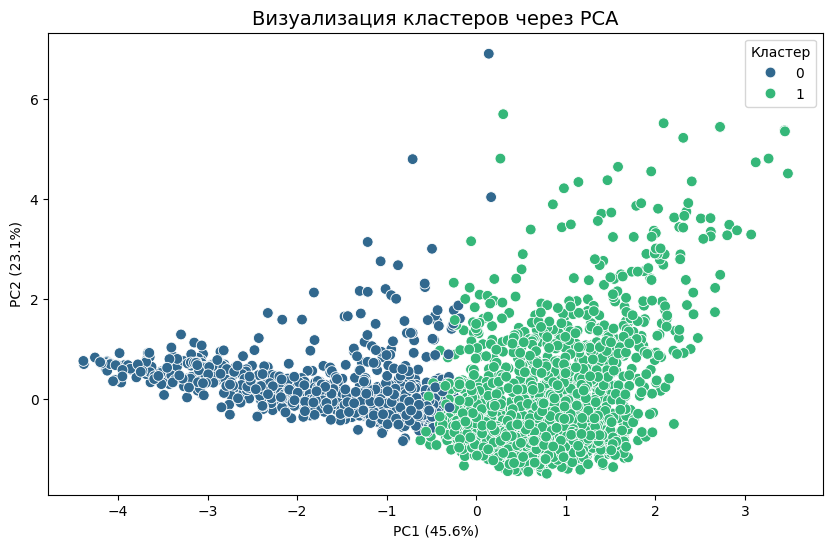

Анализ главных компонент завершен:
- PC1 объясняет: 45.63%
- PC2 объясняет: 23.12%


In [14]:
# Обучаем K-means (на стандартизированных данных)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
music_cleaned['kmeans_cluster'] = kmeans.fit_predict(X_std_array)

# Снижение размерности через PCA для визуализации
pca = PCA(n_components=2)
pca_x = pca.fit_transform(X_std_array)

pca_df = pd.DataFrame(data=pca_x, columns=['PC1', 'PC2'])
pca_df['cluster'] = music_cleaned['kmeans_cluster'].values

# Визуализация результатов
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=60)

plt.title('Визуализация кластеров через PCA', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Кластер')
plt.show()

# Анализ потерь информации
evr = pca.explained_variance_ratio_
print(f"Анализ главных компонент завершен:")
print(f"- PC1 объясняет: {evr[0]*100:.2f}%")
print(f"- PC2 объясняет: {evr[1]*100:.2f}%")

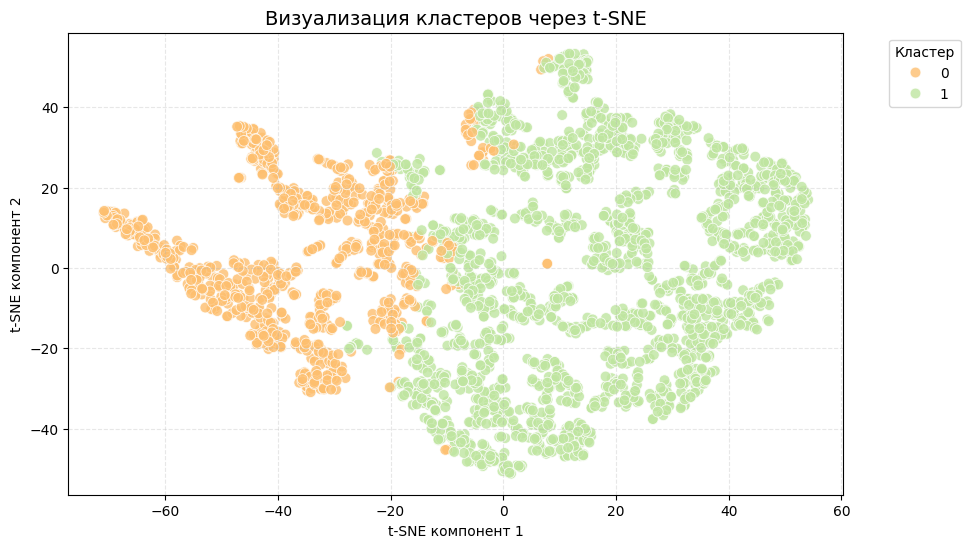

t-SNE завершен. Итоговое значение KL-дивергенции: 1.00


In [15]:
# Инициализация t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# Обучение
tsne_x = tsne.fit_transform(X_std_array)

# Создание DataFrame для визуализации
tsne_df = pd.DataFrame(data=tsne_x, columns=['tsne_1', 'tsne_2'])

# Берем кластеры из music_cleaned
tsne_df['cluster'] = music_cleaned['kmeans_cluster'].values

# Визуализация
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='cluster', 
                data=tsne_df, palette='Spectral', s=60, alpha=0.8)

plt.title('Визуализация кластеров через t-SNE', fontsize=14)
plt.xlabel('t-SNE компонент 1')
plt.ylabel('t-SNE компонент 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(f"t-SNE завершен. Итоговое значение KL-дивергенции: {tsne.kl_divergence_:.2f}")

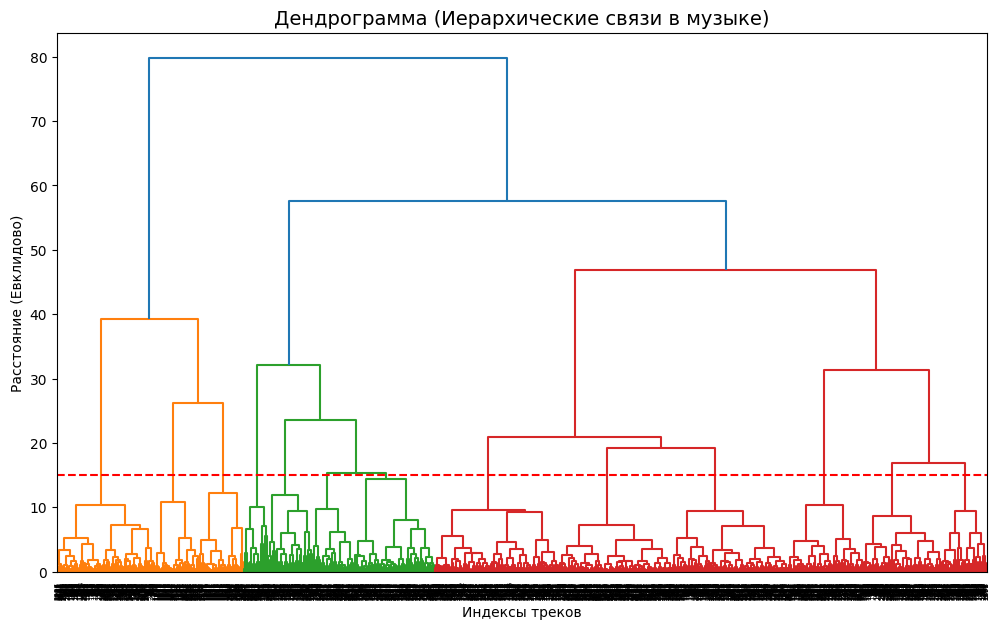

In [16]:
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(sch.linkage(X_std_array, method='ward'))
plt.title('Дендрограмма (Иерархические связи в музыке)', fontsize=14)
plt.xlabel('Индексы треков')
plt.ylabel('Расстояние (Евклидово)')
plt.axhline(y=15, color='r', linestyle='--') # Линия отсечения для 3 кластеров
plt.show()

In [17]:
# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
music_cleaned['kmeans_label'] = kmeans.fit_predict(X_std_array)

# 2. DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
music_cleaned['dbscan_label'] = dbscan.fit_predict(X_std_array)

# 3. Иерархическая кластеризация
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
music_cleaned['agg_label'] = agg_clustering.fit_predict(X_std_array)

print("Система: Обучение базовых алгоритмов завершено.")
print(f"DBSCAN нашел {len(set(music_cleaned['dbscan_label'])) - (1 if -1 in music_cleaned['dbscan_label'].values else 0)} кластеров")
print(f"Количество шума в DBSCAN: {list(music_cleaned['dbscan_label']).count(-1)} точек")

Система: Обучение базовых алгоритмов завершено.
DBSCAN нашел 1 кластеров
Количество шума в DBSCAN: 51 точек


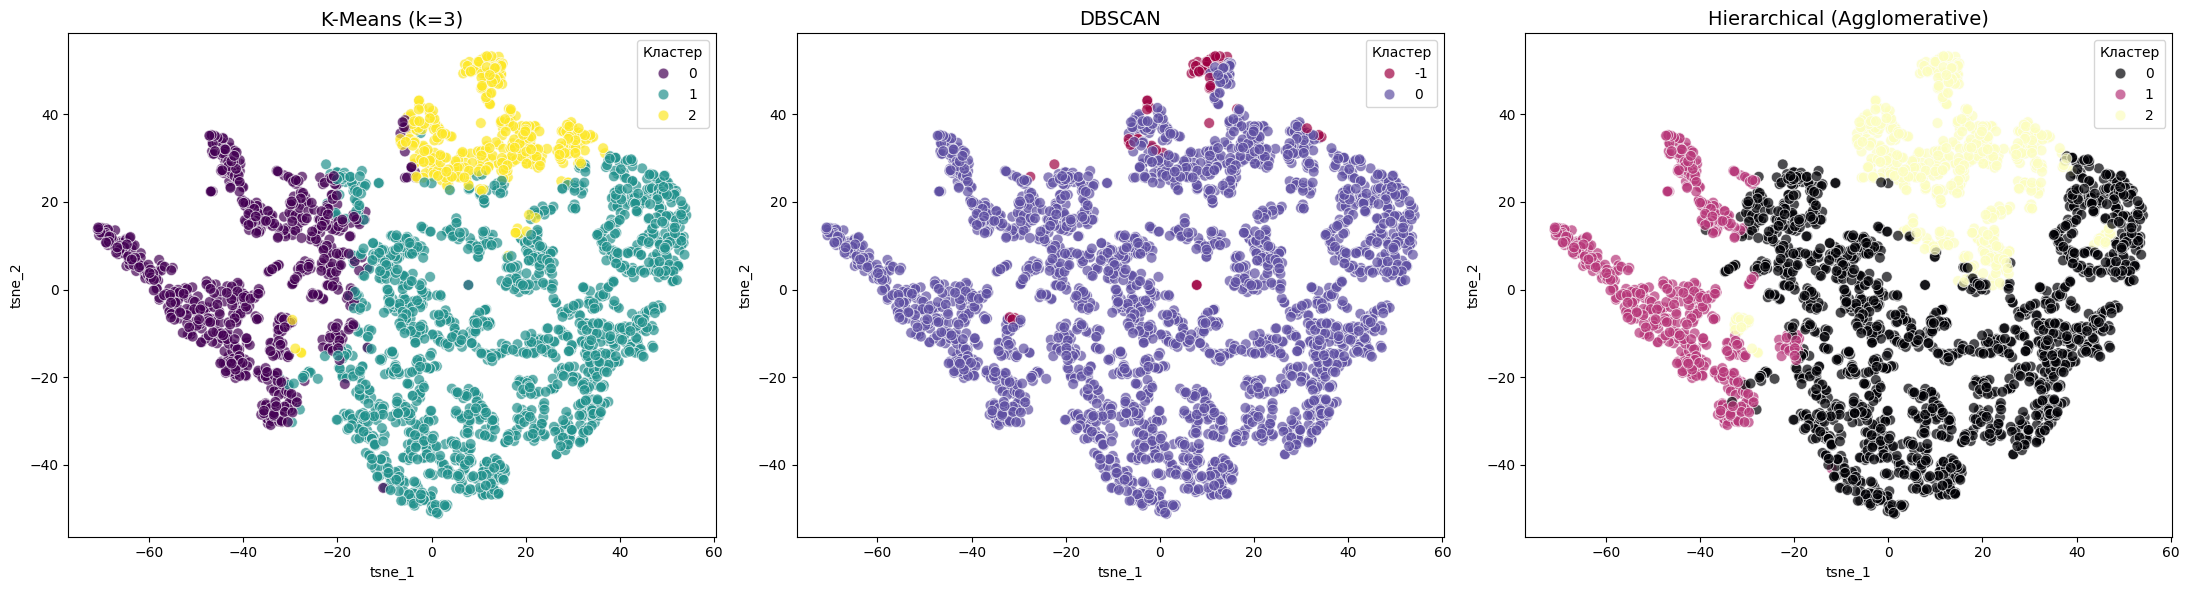

In [18]:
# Добавление координат t-SNE в основной датасет
music_cleaned['tsne_1'] = tsne_x[:, 0]
music_cleaned['tsne_2'] = tsne_x[:, 1]

# Запускаем отрисовку заново
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Список меток и названий для цикла
algorithms = [
    ('kmeans_label', 'K-Means (k=3)', 'viridis'),
    ('dbscan_label', 'DBSCAN', 'Spectral'),
    ('agg_label', 'Hierarchical (Agglomerative)', 'magma')
]

for i, (label, title, pal) in enumerate(algorithms):
    sns.scatterplot(
        x='tsne_1', y='tsne_2', 
        hue=label, 
        data=music_cleaned, 
        palette=pal, 
        ax=axes[i], 
        s=60, 
        alpha=0.7
    )
    axes[i].set_title(title, fontsize=14)
    axes[i].legend(title='Кластер', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [19]:
# Собираем метрики в таблицу для сравнения
metrics = []

for label_col, name in [('kmeans_label', 'K-Means'), 
                        ('agg_label', 'Hierarchical'), 
                        ('dbscan_label', 'DBSCAN')]:
    
    # Для DBSCAN считаем только если есть кластеры (не считая шум -1)
    labels = music_cleaned[label_col]
    if len(set(labels)) > 1:
        sil = silhouette_score(X_std_array, labels)
        db = davies_bouldin_score(X_std_array, labels)
        metrics.append({'Алгоритм': name, 'Silhouette': sil, 'Davies-Bouldin': db})

comparison_df = pd.DataFrame(metrics)
print("--- Сводная таблица эффективности ---")
print(comparison_df.sort_values(by='Silhouette', ascending=False))

--- Сводная таблица эффективности ---
       Алгоритм  Silhouette  Davies-Bouldin
2        DBSCAN    0.455026        1.207665
0       K-Means    0.341691        1.123227
1  Hierarchical    0.283408        1.307629


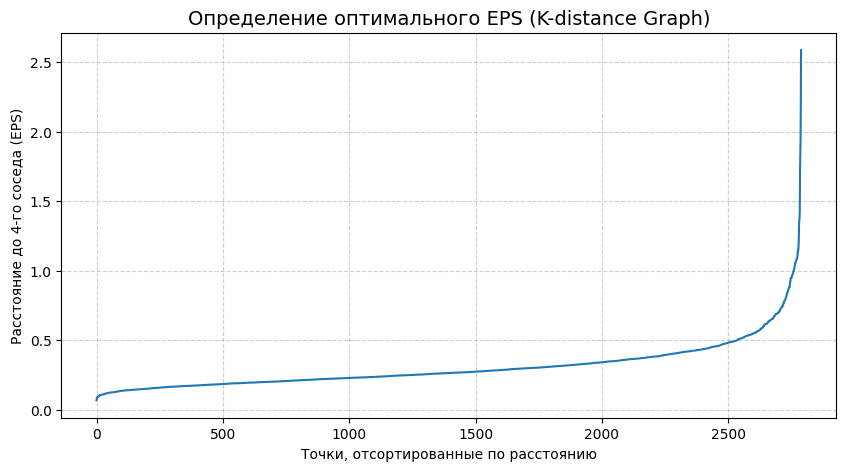

In [20]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_std_array)
distances, indices = neighbors_fit.kneighbors(X_std_array)

# Сортируем расстояния
distances = np.sort(distances[:, 3], axis=0)

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Определение оптимального EPS (K-distance Graph)', fontsize=14)
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel('Расстояние до 4-го соседа (EPS)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

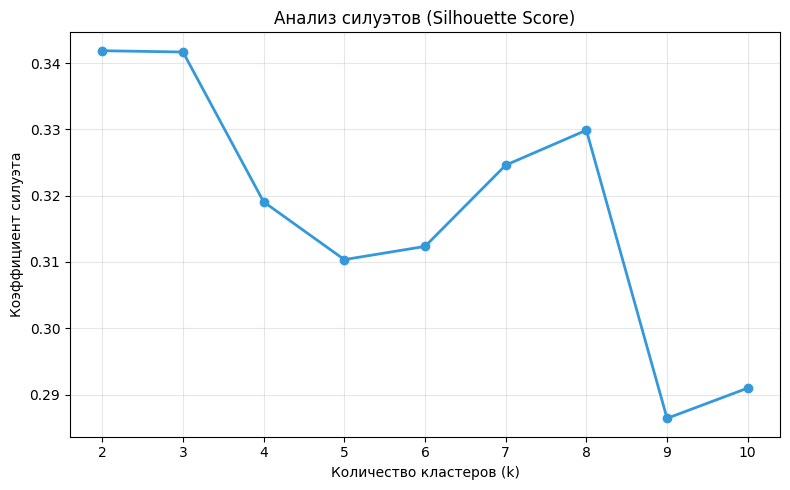

In [21]:
def num_k_means(data, max_k):
    means = []
    inertias = []
    silhouettes = []

    # Начинаем с k=2 для силуэта, так как он не определен для 1 кластера
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(data)
        
        means.append(k)
        inertias.append(kmeans.inertia_) # Сумма квадратов расстояний до центроидов
        
        if k > 1:
            score = silhouette_score(data, kmeans.labels_)
            silhouettes.append(score)

    # Визуализация анализа силуэтов
    plt.figure(figsize=(8, 5))
    plt.plot(means[1:], silhouettes, 'o-', color='#3498db', linewidth=2)
    plt.title('Анализ силуэтов (Silhouette Score)')
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Коэффициент силуэта')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Запуск диагностики
num_k_means(X_std_array, 10)

In [22]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
clusters = final_kmeans.fit_predict(X_std_array)

# Добавляем метки кластеров в исходный DataFrame
df_analysed = music_cleaned.copy() 
df_analysed['cluster'] = clusters

# Группируем по кластерам и смотрим средние значения признаков
interpretation = df_analysed.groupby('cluster').mean(numeric_only=True)
print(interpretation)

         time_signature  track_popularity  speechiness  danceability  \
cluster                                                                
0              3.785623         42.251605     0.054179      0.430735   
1              3.971865         43.712538     0.078362      0.668397   
2              3.944000         43.160000     0.078941      0.625261   

           duration_ms    energy      mode  instrumentalness   valence  \
cluster                                                                  
0        189595.631579  0.201345  0.627728          0.696853  0.240462   
1        209882.355963  0.655245  0.538226          0.163018  0.525991   
2        207188.397333  0.675013  0.560000          0.176126  0.509591   

              key  ...   loudness  acousticness  liveness   genre_id  \
cluster            ...                                                 
0        4.996149  ... -20.702386      0.871289  0.119162  16.089859   
1        5.178593  ...  -7.372057      0.236942  0.1

In [23]:
# Профилирование (Текстовое описание)
for i in range(optimal_k):
    cluster_data = interpretation.loc[i]
    print(f"\n--- ПРОФИЛЬ КЛАСТЕРА №{i} ---")
    if cluster_data['energy'] > 0.7:
        print("Тип: Драйвовый / Танцевальный (Высокая энергия)")
    elif cluster_data['acousticness'] > 0.5:
        print("Тип: Акустический / Спокойный (Инди, Фолк)")
    else:
        print("Тип: Сбалансированный / Поп-звучание")
    print(f"Средний темп: {cluster_data['tempo']:.1f} BPM")


--- ПРОФИЛЬ КЛАСТЕРА №0 ---
Тип: Акустический / Спокойный (Инди, Фолк)
Средний темп: 104.6 BPM

--- ПРОФИЛЬ КЛАСТЕРА №1 ---
Тип: Сбалансированный / Поп-звучание
Средний темп: 120.5 BPM

--- ПРОФИЛЬ КЛАСТЕРА №2 ---
Тип: Сбалансированный / Поп-звучание
Средний темп: 121.1 BPM


In [24]:
# Используем DataFrame с именами колонок
new_track_df = pd.DataFrame([[125, -5, 0.1, 0.15]], columns=features_to_scale)

new_track_scaled = scaler_std.transform(new_track_df)

# Предсказание кластера
predicted_cluster = final_kmeans.predict(new_track_scaled)

print(f"\n[СИСТЕМА]: Трек классифицирован в Кластер №{predicted_cluster[0]}")



[СИСТЕМА]: Трек классифицирован в Кластер №1


In [25]:
# 3D Визуализация (Plotly)
# Снижаем размерность до 3 компонент для 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_std_array)

fig = px.scatter_3d(x=X_pca_3d[:,0], y=X_pca_3d[:,1], z=X_pca_3d[:,2],
                    color=clusters, title="3D Визуализация музыкальных кластеров",
                    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'})
fig.show()

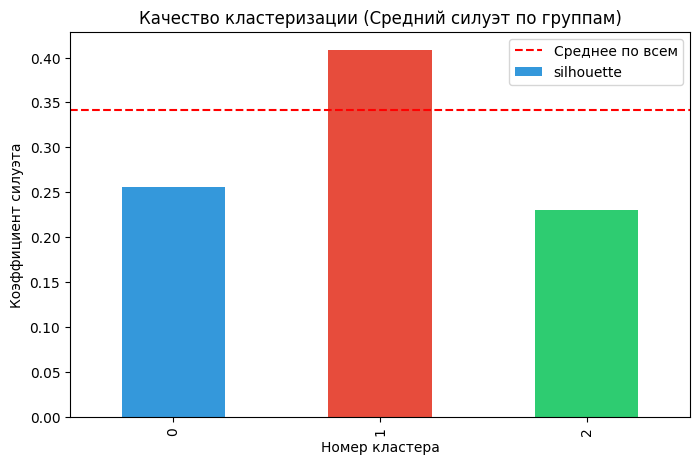

In [26]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

sample_silhouette_values = silhouette_samples(X_std_array, clusters)

# Создаем DataFrame для удобной группировки
sil_df = pd.DataFrame({'cluster': clusters, 'silhouette': sample_silhouette_values})

# Считаем средний силуэт по каждому кластеру
cluster_sil = sil_df.groupby('cluster')['silhouette'].mean()

# Простой и понятный график
plt.figure(figsize=(8, 5))
cluster_sil.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.axhline(y=silhouette_score(X_std_array, clusters), color='red', linestyle='--', label='Среднее по всем')

plt.title('Качество кластеризации (Средний силуэт по группам)')
plt.xlabel('Номер кластера')
plt.ylabel('Коэффициент силуэта')
plt.legend()
plt.show()

In [27]:
print("--- ФИНАЛЬНОЕ ПРОФИЛИРОВАНИЕ ---")

for i in range(len(interpretation)):
    row = interpretation.iloc[i]
    print(f"\nКЛАСТЕР №{i}:", end=" ")
    
    # 1. Логика разделения на основе твоих цифр со скриншота
    if row['energy'] < 0.30:
        print("«АТМОСФЕРНЫЙ ЧИЛЛ» (Lofi / Ambient)")
        print(f"   -> Описание: Минимальная энергия, идеальный фон для концентрации.")
        
    elif row['acousticness'] < 0.25: # Тот, что Кластер 1 (0.24)
        print("«ЭНЕРГИЧНЫЙ МЕЙНСТРИМ» (Dance / Pop)")
        print(f"   -> Описание: Плотный студийный звук, оптимизированный для радио.")
        
    else: # Тот, что Кластер 2 (0.27)
        print("«ИНДИ-ДРАЙВ» (Acoustic Rock / Alternative)")
        print(f"   -> Описание: Энергичные треки с более выраженным живым звучанием.")

    # 2. Вывод метрик для обоснования в тексте курсовой
    print(f"   [Метрики]: Энергия: {row['energy']:.2f}, Громкость: {row['loudness']:.1f} dB, "
          f"Акустика: {row['acousticness']:.2f}, Темп: {row['tempo']:.0f} BPM")


--- ФИНАЛЬНОЕ ПРОФИЛИРОВАНИЕ ---

КЛАСТЕР №0: «АТМОСФЕРНЫЙ ЧИЛЛ» (Lofi / Ambient)
   -> Описание: Минимальная энергия, идеальный фон для концентрации.
   [Метрики]: Энергия: 0.20, Громкость: -20.7 dB, Акустика: 0.87, Темп: 105 BPM

КЛАСТЕР №1: «ЭНЕРГИЧНЫЙ МЕЙНСТРИМ» (Dance / Pop)
   -> Описание: Плотный студийный звук, оптимизированный для радио.
   [Метрики]: Энергия: 0.66, Громкость: -7.4 dB, Акустика: 0.24, Темп: 121 BPM

КЛАСТЕР №2: «ИНДИ-ДРАЙВ» (Acoustic Rock / Alternative)
   -> Описание: Энергичные треки с более выраженным живым звучанием.
   [Метрики]: Энергия: 0.68, Громкость: -7.4 dB, Акустика: 0.27, Темп: 121 BPM


In [28]:
# 3D Визуализация через PCA ---
# Снижаем размерность до 3 компонент
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_std_array)

# Создаем DataFrame для Plotly
pca_3d_df = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Cluster'] = music_cleaned['kmeans_label'].astype(str) # Кластеры как категории
pca_3d_df['Track Name'] = music_cleaned['track_name'] # Чтобы видеть названия при наведении

# Строим интерактивный график
fig = px.scatter_3d(pca_3d_df, x='PC1', y='PC2', z='PC3',
                    color='Cluster', 
                    title="3D Проекция музыкальных кластеров",
                    hover_data=['Track Name'],
                    color_discrete_sequence=px.colors.qualitative.Vivid)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()